# 🦖 YOLOv11x Training Pipeline - Detección de Logos (Local Docker)

## 🎯 Objetivo
Este notebook entrena el modelo **YOLOv11x (Extra Large)**, la versión más potente de la arquitectura YOLOv11, para detectar logos de empresas.
El entrenamiento se realiza en **infraestructura local** utilizando un contenedor Docker con una GPU NVIDIA RTX 3050.

## ⚠️ Desafío de Hardware (4GB VRAM)
El modelo YOLOv11x es masivo (~56M parámetros). Para entrenarlo en una GPU de 4GB, utilizamos una estrategia quirúrgica:
1.  **Batch Size Reducido (2):** Para evitar desbordamiento de memoria (OOM).
2.  **Image Size (640):** Resolución estándar balanceada.
3.  **Gradient Accumulation:** El modelo compensa el batch pequeño acumulando gradientes internamente.

## 📝 Contenido
1.  **Verificación del Entorno:** GPU y librerías.
2.  **Exploración del Dataset (EDA):** Trazabilidad y visualización previa.
3.  **Configuración:** Definición de hiperparámetros y `data.yaml`.
4.  **Entrenamiento:** Ejecución del loop de entrenamiento.
5.  **Análisis de Resultados:** Interpretación de métricas y curvas de pérdida.
6.  **Validación e Inferencia:** Pruebas visuales con el modelo entrenado.
7.  **Exportación:** Guardado de pesos y resumen final.

---

## 1. 🔧 Verificación del Entorno
Comprobamos que estamos en el entorno Docker correcto y que PyTorch detecta la GPU.

In [12]:
# =============================================================================
# Environment Setup
# =============================================================================
import torch
import ultralytics
import os
import cv2
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import glob
from datetime import datetime
from IPython.display import Image, display

# Configure matplotlib for inline display
%matplotlib inline

print(f"✅ Ultralytics version: {ultralytics.__version__}")
print(f"✅ PyTorch version: {torch.__version__}")

# Check CUDA availability
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🚀 GPU Detectada: {gpu_name} ({gpu_mem:.2f} GB VRAM)")
else:
    print("❌ ERROR: No se detecta GPU. El entrenamiento será extremadamente lento.")

✅ Ultralytics version: 8.4.9
✅ PyTorch version: 2.1.0+cu118
🚀 GPU Detectada: NVIDIA GeForce RTX 3050 4GB Laptop GPU (4.29 GB VRAM)


## 2. 📁 Exploración del Dataset
Analizamos la estructura del dataset montado en `/workspace/dataset_yolov8` y generamos un archivo de configuración adaptado al entorno local.

In [13]:
# =============================================================================
# Dataset Configuration (Local Paths)
# =============================================================================
# Define absolute paths for Docker environment
WORKSPACE_DIR = "/workspace"
DATASET_DIR = f"{WORKSPACE_DIR}/dataset_yolov8"

# 1. Create a local-specific YAML file
# This ensures paths are correct regardless of how the dataset was downloaded
ORIGINAL_YAML = f"{DATASET_DIR}/data.yaml"
LOCAL_YAML = f"{DATASET_DIR}/data_local_v11x.yaml"

if os.path.exists(ORIGINAL_YAML):
    with open(ORIGINAL_YAML, 'r') as f:
        data_config = yaml.safe_load(f)
    
    # Update paths to be absolute inside Docker
    data_config['path'] = DATASET_DIR
    data_config['train'] = "train/images"
    data_config['val'] = "valid/images"
    data_config['test'] = "test/images"
    
    # Save the new config
    with open(LOCAL_YAML, 'w') as f:
        yaml.dump(data_config, f)
        
    print(f"✅ Configuración YAML generada: {LOCAL_YAML}")
    print(f"📊 Clases detectadas: {data_config.get('nc', 'Unknown')}")
else:
    print("❌ ERROR CRÍTICO: No se encuentra data.yaml en la ruta esperada.")

✅ Configuración YAML generada: /workspace/dataset_yolov8/data_local_v11x.yaml
📊 Clases detectadas: 175


### 2.1 Visualización de Muestras
Antes de entrenar, verificamos visualmente que las imágenes sean accesibles y se carguen correctamente.

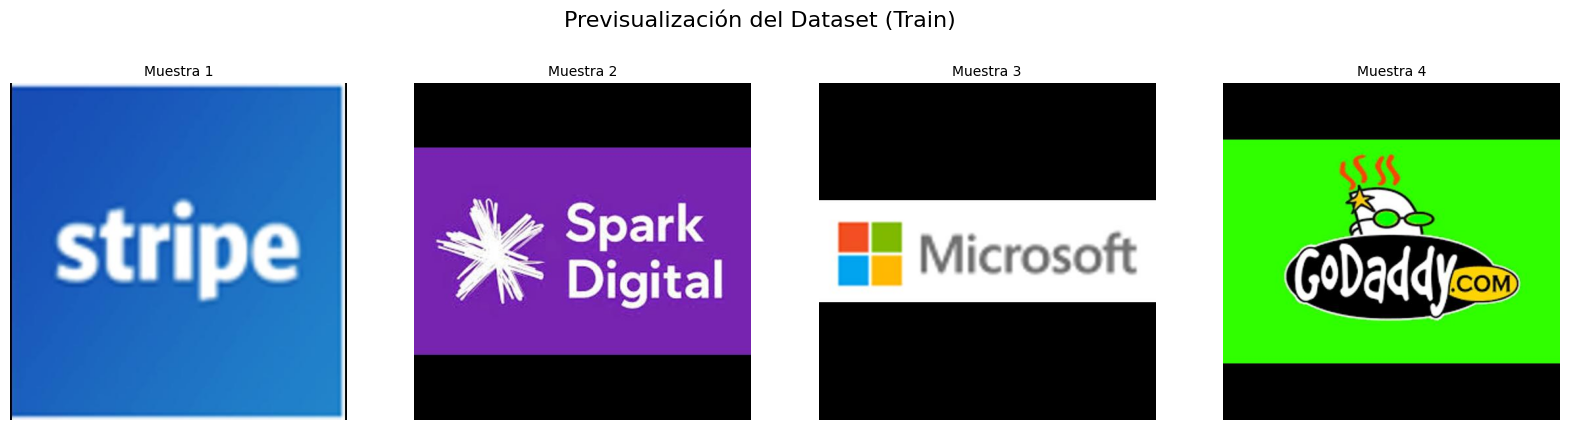

In [14]:
# =============================================================================
# Dataset Sample Visualization
# =============================================================================
# Display 4 random images from the training set to verify data integrity
train_images = glob.glob(f"{DATASET_DIR}/train/images/*.jpg")

if len(train_images) > 0:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for i in range(4):
        if i < len(train_images):
            img_path = train_images[i]
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i].imshow(img)
                axes[i].axis('off')
                axes[i].set_title(f"Muestra {i+1}", fontsize=10)
    plt.suptitle("Previsualización del Dataset (Train)", fontsize=16)
    plt.show()
else:
    print("⚠️ No se encontraron imágenes .jpg en la carpeta de entrenamiento.")

## 3. ⚙️ Configuración de Hiperparámetros

Definimos los parámetros clave para el entrenamiento. Estos valores están **estrictamente optimizados** para 4GB de VRAM.

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| `MODEL_NAME` | **yolo11x.pt** | Modelo base (Extra Large). Máxima precisión, mayor coste computacional. |
| `EPOCHS` | **50-100** | Cantidad de pasadas completas por el dataset. |
| `BATCH_SIZE` | **2** | Imágenes procesadas simultáneamente. **CRÍTICO:** Subir esto causará OOM. |
| `IMG_SIZE` | **640** | Resolución de entrada. Reducir a 512 si falla. |
| `PATIENCE` | **15** | Parada temprana si no mejora la métrica fitness por 15 épocas. |
| `WORKERS` | **1** | Hilos de carga de datos (bajo para ahorrar RAM del sistema). |

In [15]:
# =============================================================================
# Hyperparameters Configuration
# =============================================================================

MODEL_NAME = "yolo11x.pt"  # Pretrained weights
EXPERIMENT_NAME = "logo_detection_yolo11x_local"
PROJECT_DIR = "/workspace/runs/detect"

EPOCHS = 100
BATCH_SIZE = 2      # Adapted for 4GB VRAM
IMAGE_SIZE = 640
PATIENCE = 15
WORKERS = 1
DEVICE = 0

print("="*60)
print("🔧 CONFIGURACIÓN DEL EXPERIMENTO (LOCAL LOW-VRAM)")
print("="*60)
print(f" Modelo Base:      {MODEL_NAME}")
print(f" Experimento:      {EXPERIMENT_NAME}")
print(f" Épocas:           {EPOCHS}")
print(f" Batch Size:       {BATCH_SIZE} (Límite físico)")
print(f" Resolución:       {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f" Patience:         {PATIENCE}")
print("="*60)

🔧 CONFIGURACIÓN DEL EXPERIMENTO (LOCAL LOW-VRAM)
 Modelo Base:      yolo11x.pt
 Experimento:      logo_detection_yolo11x_local
 Épocas:           100
 Batch Size:       2 (Límite físico)
 Resolución:       640x640
 Patience:         15


## 4. 🏋️ Entrenamiento del Modelo

Iniciamos el proceso de Fine-Tuning. YOLO se encargará de descargar los pesos automáticamente si no existen.

### 📉 Guía de Métricas en Vivo:
*   **GPU_mem:** Uso de memoria de video. Si se acerca a 4G, peligro.
*   **box_loss:** Error en las coordenadas de las cajas (debe bajar).
*   **cls_loss:** Error en la clasificación de objetos (debe bajar).
*   **dfl_loss:** Distribution Focal Loss (precisión fina de bordes).
*   **Instances:** Número de objetos vistos en el batch actual.
*   **Size:** Resolución de entrada actual.

In [ ]:
from ultralytics import YOLO

# =============================================================================
# Model Training
# =============================================================================

# Load pretrained model
model = YOLO(MODEL_NAME)

print(f"🚀 Iniciando entrenamiento de {MODEL_NAME}...")
print("⏳ Esto puede tardar varias horas. ¡Paciencia!")

# Start training
results = model.train(
    data=LOCAL_YAML,
    epochs=EPOCHS,
    patience=PATIENCE,
    batch=BATCH_SIZE,
    imgsz=IMAGE_SIZE,
    device=DEVICE,
    workers=WORKERS,
    project=PROJECT_DIR,
    name=EXPERIMENT_NAME,
    exist_ok=True,
    save=True,
    pretrained=True,
    optimizer='auto',
    verbose=True,
    plots=True,
    amp=True  # Automatic Mixed Precision (Crucial for memory saving)
)

🚀 Iniciando entrenamiento de yolo11x.pt...
⏳ Esto puede tardar varias horas. ¡Paciencia!
Ultralytics 8.4.9 🚀 Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 4GB Laptop GPU, 4096MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspace/dataset_yolov8/data_local_v11x.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_s

## 5. 📊 Análisis de Resultados

Una vez completado el entrenamiento, analizamos visual y numéricamente el desempeño.

### Glosario de Métricas:
*   **mAP50 (Mean Average Precision @ IoU 0.5):** La métrica "reina". Indica qué tan preciso es el modelo considerando un solapamiento del 50% como válido. Queremos que sea cercano a 1.0.
*   **mAP50-95:** Un promedio más estricto (IoU de 0.5 a 0.95). Refleja la precisión "perfecta".
*   **Precision (P):** De todo lo que detectó, ¿cuánto era real? (Evita falsos positivos).
*   **Recall (R):** De todo lo real que había, ¿cuánto detectó? (Evita falsos negativos).

In [ ]:
# =============================================================================
# Results Visualization
# =============================================================================
RESULTS_DIR = f"{PROJECT_DIR}/{EXPERIMENT_NAME}"
CSV_PATH = f"{RESULTS_DIR}/results.csv"
PNG_RESULTS = f"{RESULTS_DIR}/results.png"
PNG_CONFUSION = f"{RESULTS_DIR}/confusion_matrix.png"

# 1. Load and display numerical metrics
if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    # Remove spaces from column names
    df.columns = df.columns.str.strip()
    
    # Find best epoch based on mAP50
    if not df.empty:
        best_idx = df['metrics/mAP50(B)'].idxmax()
        best_epoch = df.loc[best_idx]
        
        print("\n🏆 MEJOR RESULTADO OBTENIDO:")
        print(f"   - Época:       {best_epoch['epoch']}")
        print(f"   - mAP@50:      {best_epoch['metrics/mAP50(B)']:.4f}")
        print(f"   - mAP@50-95:   {best_epoch['metrics/mAP50-95(B)']:.4f}")
        print(f"   - Precision:   {best_epoch['metrics/precision(B)']:.4f}")
        print(f"   - Recall:      {best_epoch['metrics/recall(B)']:.4f}")
    else:
        print("⚠️ El archivo de resultados está vacío.")

# 2. Display Training Curves
print("\n📈 Curvas de Entrenamiento (Loss, Precision, Recall, mAP):")
if os.path.exists(PNG_RESULTS):
    display(Image(PNG_RESULTS, width=800))
else:
    print("⚠️ No se encontró la imagen results.png")

# 3. Display Confusion Matrix
print("\nYR Matriz de Confusión:")
if os.path.exists(PNG_CONFUSION):
    display(Image(PNG_CONFUSION, width=800))
else:
    print("⚠️ No se encontró la matriz de confusión (quizás el entreno no terminó).")

## 6. 🔍 Validación e Inferencia
Realizamos una validación final y probamos el modelo con imágenes que nunca ha visto (Test Set).

### 6.1 Validación Técnica

In [ ]:
# =============================================================================
# Model Validation
# =============================================================================
print("🧪 Ejecutando Validación en el set 'val'...")

BEST_WEIGHTS = f"{RESULTS_DIR}/weights/best.pt"

if os.path.exists(BEST_WEIGHTS):
    # Load the best model trained
    val_model = YOLO(BEST_WEIGHTS)
    
    # Run validation
    val_metrics = val_model.val(data=LOCAL_YAML, split='val')
    
    print(f"✅ Validación Final mAP50: {val_metrics.box.map50:.4f}")
else:
    print("⚠️ No se encontraron los pesos del mejor modelo (best.pt).")

### 6.2 Inferencia Visual
Tomamos 3 imágenes aleatorias del set de prueba y dibujamos las cajas predichas.

In [ ]:
# =============================================================================
# Setup Inference Visualization
# =============================================================================
test_images = glob.glob(f"{DATASET_DIR}/test/images/*.jpg")[:3]

if len(test_images) > 0 and os.path.exists(BEST_WEIGHTS):
    print(f"🔮 Realizando inferencia en {len(test_images)} imágenes de prueba...")
    
    # Load model if not loaded
    pred_model = YOLO(BEST_WEIGHTS)
    
    # Predict
    results = pred_model.predict(test_images, conf=0.40) # Confidence threshold

    # Display
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    for i, r in enumerate(results):
        # Plot results (returns numpy array in BGR)
        im_array = r.plot()
        # Convert to RGB for matplotlib
        im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)
        
        if i < 3:
            axes[i].imshow(im_rgb)
            axes[i].axis('off')
            axes[i].set_title(f"Predicción {i+1}", fontsize=12)
    plt.show()
else:
    print("⚠️ No hay imágenes de prueba o no hay modelo entrenado.")

## 7. 💾 Resumen y Exportación
Guardamos una copia segura del modelo y generamos un reporte final.

In [ ]:
import shutil

# =============================================================================
# Experiment Summary & Export
# =============================================================================

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M")
EXPORT_DIR = "/workspace/models"
FINAL_MODEL_NAME = f"best_yolo11x_local_{TIMESTAMP}.pt"

os.makedirs(EXPORT_DIR, exist_ok=True)

print("="*70)
print("                    RESUMEN FINAL DEL EXPERIMENTO                   ")
print("="*70)

if os.path.exists(BEST_WEIGHTS):
    # 1. Save copy of the model
    shutil.copy(BEST_WEIGHTS, f"{EXPORT_DIR}/{FINAL_MODEL_NAME}")
    
    print(f"✅ Modelo Guardado:   {EXPORT_DIR}/{FINAL_MODEL_NAME}")
    
    # 2. Try export to ONNX (Optional)
    print("📦 Exportando a ONNX... (Opcional)")
    try:
        model.export(format='onnx')
        print("   -> Exportación ONNX exitosa.")
    except Exception as e:
        print(f"   -> No se pudo exportar a ONNX (no crítico): {e}")
else:
    print("❌ ERROR: No se encontró el archivo de pesos finales.")

print("\n📝 PRÓXIMOS PASOS:")
print("1. Si el mAP@50 es bajo (<0.5), revisa la calidad de las etiquetas.")
print("2. Intenta aumentar EPOCHS si las curvas de Loss siguen bajando.")
print("3. Usa este modelo en el backend copiándolo a la carpeta /app/models.")
print("="*70)